# Local heroes

This notebook aims to identify which festivals book the highest share of artists from their own country, and which book the least.

In [1]:
import pandas as pd
from festival_analysis.analysis_utils import query_db
import seaborn as sns
from matplotlib import pyplot as plt
from tabulate import tabulate

plt.style.use("ggplot")
%matplotlib inline

pd.options.display.float_format = "{:,.2f}".format

## Data pull

In [2]:
query_local_heroes = """
SELECT
  festival_id||'-'||edition_year||'-'||artist_id AS booking_id,
  festival_id,
  festival_name,
  edition_year,
  festival_name||'-'||edition_year AS edition_name,
  size_band,
  location_country,
  artist_id,
  display_name,
  artist_country
FROM edition_lineups
WHERE edition_year NOT IN (2020, 2021)
"""

df = query_db(query_local_heroes)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49547 entries, 0 to 49546
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   booking_id        49547 non-null  object
 1   festival_id       49547 non-null  int64 
 2   festival_name     49547 non-null  object
 3   edition_year      49547 non-null  int32 
 4   edition_name      49547 non-null  object
 5   size_band         49547 non-null  object
 6   location_country  49547 non-null  object
 7   artist_id         49547 non-null  int64 
 8   display_name      49547 non-null  object
 9   artist_country    47996 non-null  object
dtypes: int32(1), int64(2), object(7)
memory usage: 3.6+ MB


,booking_id,festival_id,festival_name,edition_year,edition_name,size_band,location_country,artist_id,display_name,artist_country
0,5472842727274810663-2010-2458179974470344057,5472842727274810663,Drift,2010,Drift-2010,2 - S,NL,2458179974470344057,Eric de Man,NL
1,6434180066063891417-2025-2045920812929791265,6434180066063891417,Queen's Park Glasgow,2025,Queen's Park Glasgow-2025,1 - XS,GB,2045920812929791265,Fourth Precinct,GB
2,1708315861235644776-2015-1280847534394918768,1708315861235644776,Chateau Perche,2015,Chateau Perche-2015,2 - S,FR,1280847534394918768,Milan Kobar,FR
3,2648629204636342015-2022-722411156191061301,2648629204636342015,DGTL,2022,DGTL-2022,4 - L,NL,722411156191061301,Polo & Pan,None
4,4821747995330768198-2024-3703370115178342908,4821747995330768198,Distortion,2024,Distortion-2024,5 - XL,DK,3703370115178342908,Sven Dohse,DE


## Housekeeping

Define some helper functions for use in the analysis later.

In [3]:
def aggregate_home_bookings(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    if not "country_match" in df.columns:
        if {"location_country", "artist_country"}.issubset(set(df.columns)):
            df["country_match"] = df["artist_country"] == df["location_country"]
        else:
            raise ValueError(
                'Cannot construct "country_match" column without "location_country" and "artist_country" in DataFrame.'
            )

    df_agg = (
        df.groupby(group_cols)
        .agg(
            bookings=("booking_id", "nunique"),
            home_country_bookings=("country_match", "sum"),
        )
        .reset_index()
    )
    df_agg["home_country_booking_rate"] = (
        df_agg["home_country_bookings"] / df_agg["bookings"]
    )
    return df_agg

## Analysis

Let's start by grouping by location country.

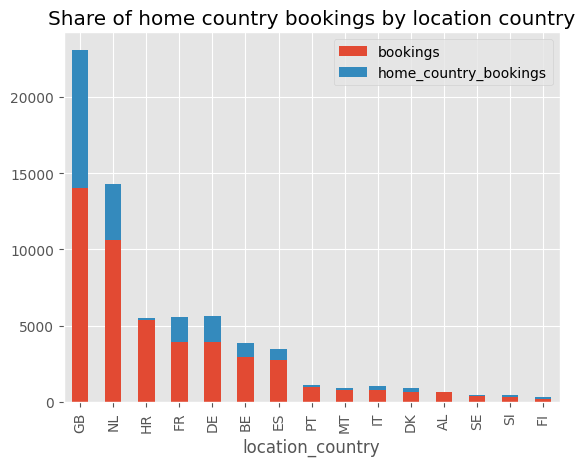

In [4]:
df_location_countries = aggregate_home_bookings(df, ["location_country"])
(
    df_location_countries.sort_values("bookings", ascending=False)
    .set_index("location_country")[["bookings", "home_country_bookings"]][:15]
    .plot(
        kind="bar",
        stacked=True,
        title="Share of home country bookings by location country",
    )
)
plt.show()

The UK does especially well on booking home-grown artists, which makes sense due to the rich history of electronic music there. 

Netherlands, France, Germany, Belgium and Spain have pretty similar shares of home-country bookings. 

Croatia does especially poorly here, primarily because most festivals taking place in Croatia are run by UK-based promoters (destination/jet set festivals). In fact, several Croatian festival editions booked zero Croatian artists:

In [5]:
df_editions = aggregate_home_bookings(df, ["location_country", "edition_name"])
df_editions.query('location_country == "HR" and home_country_booking_rate == 0')

,location_country,edition_name,bookings,home_country_bookings,home_country_booking_rate
554,HR,Dekmantel Selectors-2016,59,0,0.00
555,HR,Dekmantel Selectors-2017,61,0,0.00
556,HR,Dekmantel Selectors-2018,66,0,0.00
557,HR,Dekmantel Selectors-2019,58,0,0.00
560,HR,Dekmantel Selectors-2024,78,0,0.00
571,HR,Dimensions-2023,130,0,0.00
578,HR,Love International-2015,4,0,0.00
588,HR,Outlook-2008,23,0,0.00
589,HR,Outlook-2009,31,0,0.00
591,HR,Outlook-2011,62,0,0.00


Which decent-size festivals book the highest share of home-grown artists?

In [6]:
min_bookings = 20
df_festivals = aggregate_home_bookings(df, ["location_country", "festival_name"])
df_festivals[df_festivals["bookings"] > min_bookings].sort_values(
    "home_country_booking_rate", ascending=False
).head(20)

,location_country,festival_name,bookings,home_country_bookings,home_country_booking_rate
51,GB,Another Thought,49,45,0.92
68,GB,Little Fields,70,62,0.89
81,GB,Queen's Yard,892,763,0.86
86,GB,Westival,225,186,0.83
61,GB,Funk In The Forest,66,54,0.82
70,GB,Love Saves The Day,722,589,0.82
72,GB,Mimo,106,86,0.81
87,GB,Wild Wood,100,81,0.81
52,GB,Appetite on the Farm,307,240,0.78
78,GB,Pavilion,65,50,0.77


Almost entirely British festivals. How is it distributed by size band?

In [7]:
df_size_bands = aggregate_home_bookings(
    # Filter out Croatia to avoid skew.
    df.query('location_country != "HR"'),
    ["size_band"],
)
df_size_bands

,size_band,bookings,home_country_bookings,home_country_booking_rate
0,1 - XS,6271,3147,0.50
1,2 - S,14875,6810,0.46
2,3 - M,14466,6405,0.44
3,4 - L,5054,1704,0.34
4,5 - XL,3498,1068,0.31


Home country booking share decreases as festivals get bigger. 

Small festivals tend to book more artists from their home country rather than flying in a high share of foreign artists. Large festivals have the budget and the financial pressure to fly in more exclusive foreign artists.